In [3]:
from util import go_to_project_root
go_to_project_root()

CWD changed to the project root: /home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/HW1


# Pregunta 3

In [46]:
import numpy as np
import matplotlib.pyplot as plt 

from source.models.arma import ARMA
from source.utils import plot as uplot 
from source.data.loaders import create_dataset
from source.utils.plot import plot_forecast
from source.optimize.parallel import parallel_bootstrap_hr
from source.data.preprocessing import split_dataset

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Analisis exploratorio

El archivo `base_25.xls` contiene información mensual del 
- IPC (P), 
- IMACEC (Y), 
- Tasa de Política Monetaria (I). 

La funcion `create_dataset` lee los datos y transforma cada serie segun las siguintes definiciones: 
- $\pi_t = \ln(P_t/P_{t-1})$ (Tasa de cambio del IPC) 
- $y_t = \ln(Y_t/Y_{t-1})$ (Tasa de cambio del IMACEC)
- $i_t = I_t/100$. (Tasa de politica monetaria)

In [5]:
dataset = create_dataset('./data/base_25.xls')
dataset.keys()

[INFO] Data loaded successfully!


dict_keys(['t', 'pi_t', 'y_t', 'i_t'])

### Evaluando estacionalidad

Para evaluar estacionalidad utilizaremos 3 enfoques: 
1. Inspeccion visual de la serie de tiempo 
2. Inspeccion visual de la Funcion de Autocorrelacion (ACF) y Funcion de Autocorrelacion Parcial (PACF)
3. Analisis de medidas de tendencia central

Partimos por observar las series de tiempo, 

✅ Successfully saved figure to ./presentation/figures/p3/raw_series.pdf


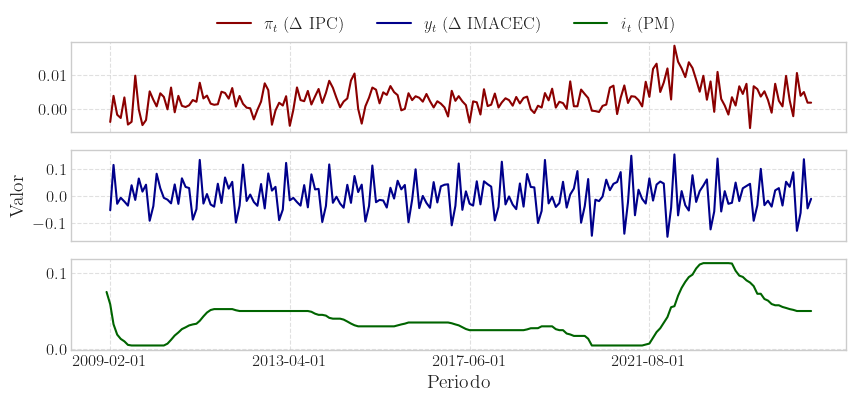

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 4), sharex=True)
fig, axes = uplot.plot_series_p3(dataset, fig, axes)
uplot.save_figure(fig, './presentation/figures/p3/raw_series.pdf')

A simple vista podemos ver que la tasa de cambio del IMACEC exhibe peaks periodicos, potencialmente patrones estacionales. 

##### ACF y PACF en la Inflacion $(\pi_t)$

✅ Successfully saved figure to ./presentation/figures/p3/acf_pacf_ipc.pdf


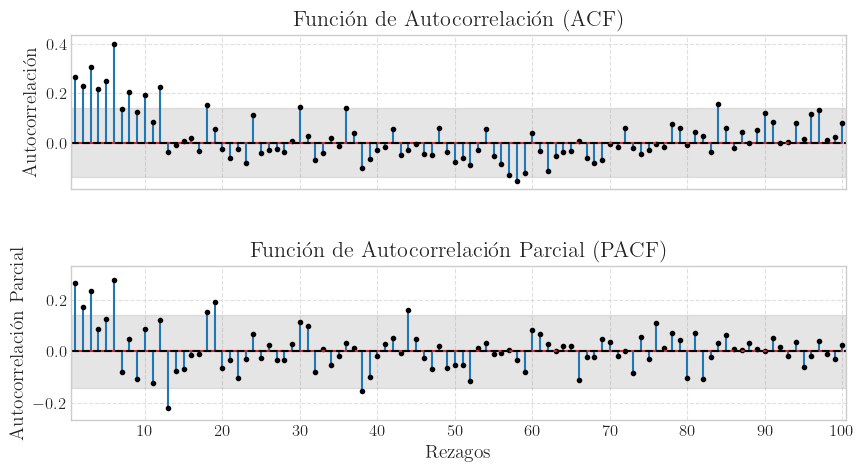

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, gridspec_kw={'hspace':0.5})
fig, axes = uplot.plot_acf_pacf(dataset['pi_t'], lags= 100, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/acf_pacf_ipc.pdf')

Al observar la figura podemos ver que no existen patrones significativos que permitan afirmar una estacionalidad evidente. Sin embargo desde la ACF se desprende que aproximadamente hasta el rezago 20 se tiene una autocorrelacion significativa entre las obervaciones. Lo anterior se confirma con el PACF el cual muestra los rezagos ajustados desde un AR truncado. Como se puede ver en la iamgen los valores significativos comprenden un rango menor que 20

##### ACF y PACF en el IMACEC

✅ Successfully saved figure to ./presentation/figures/p3/acf_pacf_imacec.pdf


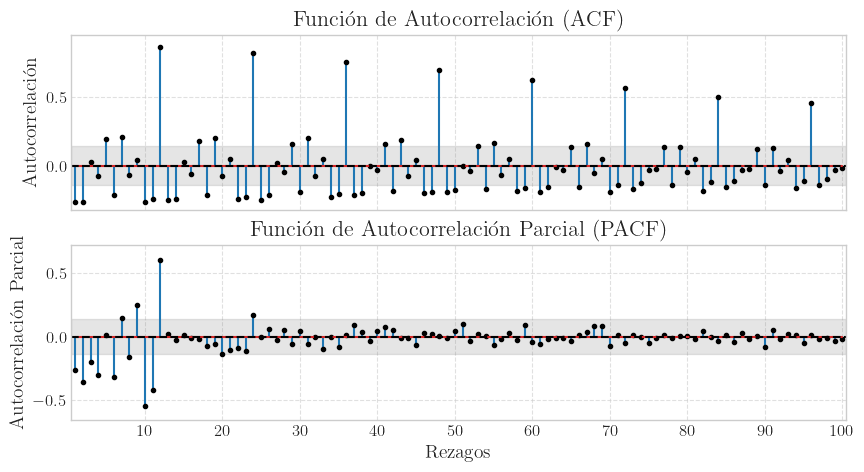

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
fig, axes = uplot.plot_acf_pacf(dataset['y_t'], lags= 100, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/acf_pacf_imacec.pdf')

Desde el ACF se ve una estacionalidad significativa cada $\sim 12$ rezagos. 

Desde el PACF podemos observar que hasta el rezago $\sim 12$ existe significancia de correlacion despues de haber contorolado por los rezagos anteriores. 

##### ACF y PACF en la Tasa de Politica Monetaria ($i_t$)

✅ Successfully saved figure to ./presentation/figures/p3/acf_pacf_tpm.pdf


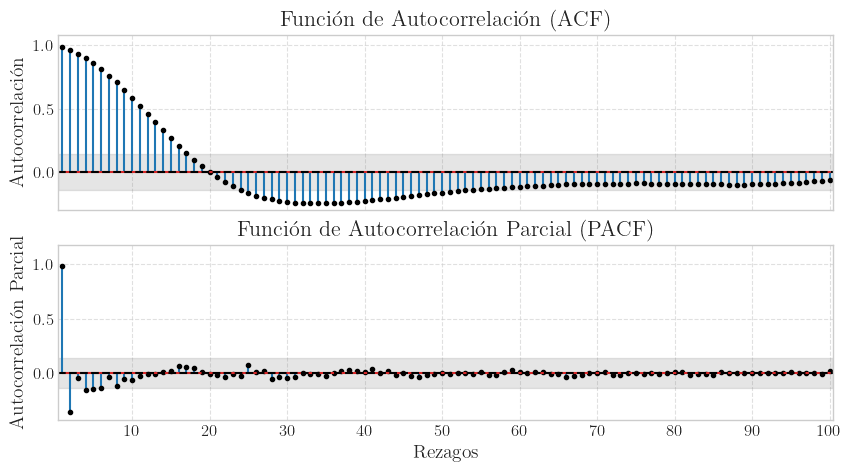

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
fig, axes = uplot.plot_acf_pacf(dataset['i_t'], lags= 100, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/acf_pacf_tpm.pdf')

La ACF para la tasa de politica monetaria muestra un decaimiento muy lento y gradual. Esto indica que el proceso es altamente no estacionario, y con alta persistencia. En otras palabras, el valor de la TPM en un periodo esta fuertemente correlacionado con sus valores en periodos anteriores. Una decisión de política monetaria de hoy tiene efectos duraderos en el futuro lo cual impidie que la tasa revierta a un promedio historico.

Desde la PACF vemos un pico muy grande en el primer rezago y un efecto negativo en el segundo, pero de menor magnitud. Esto sugiere que el proceso es similar a un $AR(\sim 1)$ donde el valor del futuro depende altamente del periodo inmediatamente anterior y los otros valores son irrelevantes para el valor actual.

/home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/HW1/source/utils/plot.py:277: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(month_names, fontsize=FONT_SIZES['tick'])


✅ Successfully saved figure to ./presentation/figures/p3/med_ipc.pdf


/home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/HW1/source/utils/plot.py:277: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(month_names, fontsize=FONT_SIZES['tick'])


✅ Successfully saved figure to ./presentation/figures/p3/med_imacec.pdf


/home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/HW1/source/utils/plot.py:277: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(month_names, fontsize=FONT_SIZES['tick'])


✅ Successfully saved figure to ./presentation/figures/p3/med_tpm.pdf


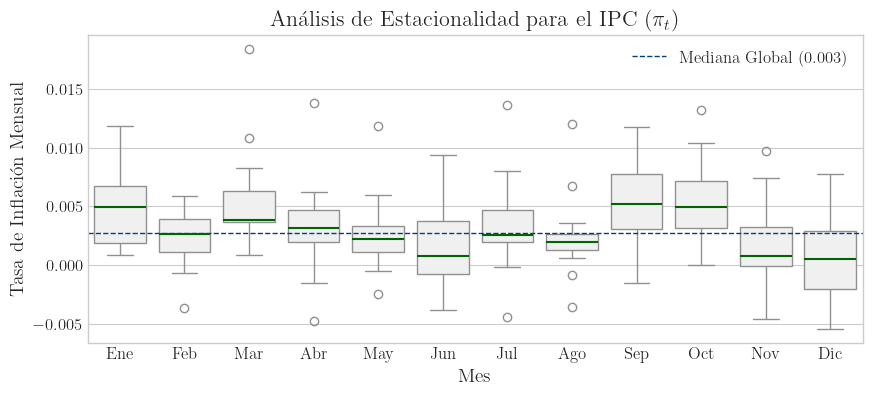

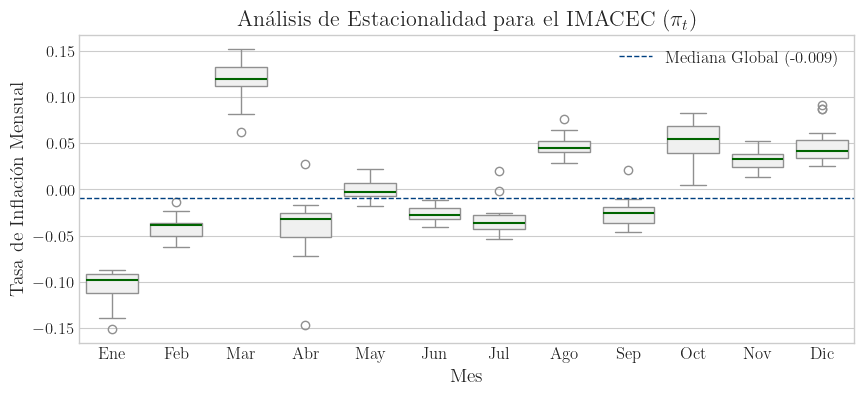

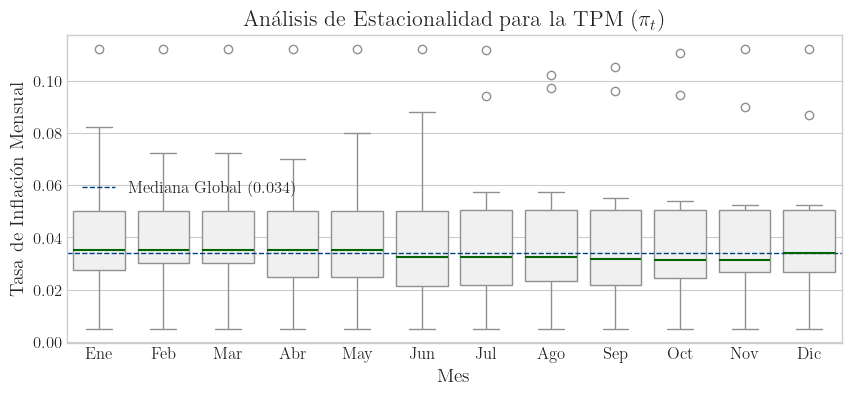

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
uplot.plot_monthly_boxplot(dataset['t'][1:], dataset['pi_t'], 
                           title=r'Análisis de Estacionalidad para el IPC ($\pi_t$)',
                           ylabel='Tasa de Inflación Mensual',
                           fig=fig, ax=ax)
uplot.save_figure(fig, './presentation/figures/p3/med_ipc.pdf')
fig, ax = plt.subplots(figsize=(10, 4))
uplot.plot_monthly_boxplot(dataset['t'][1:], dataset['y_t'], 
                           title=r'Análisis de Estacionalidad para el IMACEC ($\pi_t$)',
                           ylabel='Tasa de Inflación Mensual',
                           fig=fig, ax=ax)
uplot.save_figure(fig, './presentation/figures/p3/med_imacec.pdf')

fig, ax = plt.subplots(figsize=(10, 4))
uplot.plot_monthly_boxplot(dataset['t'], dataset['i_t'], 
                           title=r'Análisis de Estacionalidad para la TPM ($\pi_t$)',
                           ylabel='Tasa de Inflación Mensual',
                           fig=fig, ax=ax)
uplot.save_figure(fig, './presentation/figures/p3/med_tpm.pdf')

#### Determinando el p y q

In [37]:
phi_real   = [0.7, 0.2]
theta_real = [-0.4]
model = ARMA(c=0.5, sigma=1.0, phi_params=phi_real, theta_params=theta_real)
y = model.sample(n_samples=500, burn_in=100)

In [38]:
results = parallel_bootstrap_hr(y, 
                                iterations=100, 
                                j_max=5,
                                model_generator=model,
                                criteria='hqic',
                                n_jobs=4)


Starting 100-iteration parallel bootstrap...
Using given DGP to generate bootstrap series...



























Processing bootstrap iterations: 100%|██████████| 100/100 [00:37<00:00,  2.69it/s]



Bootstrap complete! Most stable pair: (2,1) [43/100 successful iterations]
Refitting the final model on the original data using MLE...


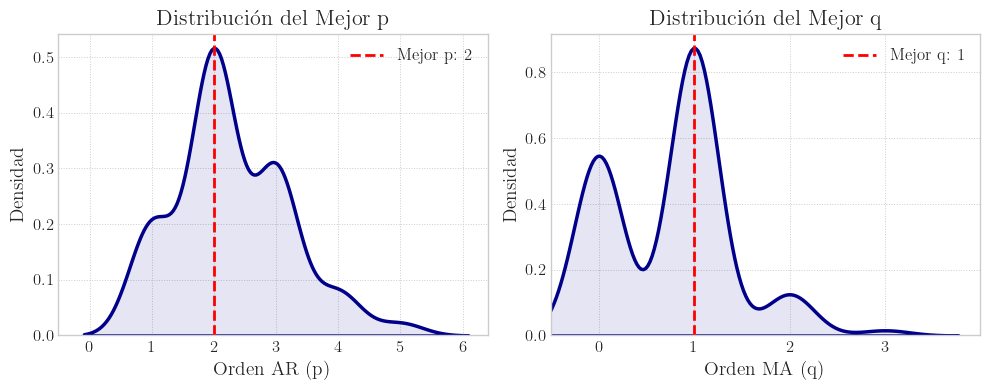

✅ Successfully saved figure to ./presentation/figures/p3/diosito.pdf


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig, axes = uplot.plot_bootstrap_kde(results, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/diosito.pdf')

### Usando los datos reales

Desde el procedimiento anterior podemos decir que los valores para $p$ y $q$ oscilan entre los 0 y ~15 rezagos. Sin embargo, para evaluar correctamente utilizaremos el metodo Hannan Rissanen.

In [40]:
criteria = 'hqic' # hqic
results_imacec = parallel_bootstrap_hr(dataset['y_t'], 
                                    iterations=30, 
                                    j_max=15, 
                                    criteria=criteria,
                                    sampling='windows',
                                    n_jobs=8)

results_ipc = parallel_bootstrap_hr(dataset['pi_t'], 
                                    iterations=15, 
                                    j_max=20, 
                                    sampling='windows',
                                    criteria=criteria,
                                    n_jobs=8)

results_tpm = parallel_bootstrap_hr(dataset['i_t'], 
                                    iterations=15, 
                                    j_max=20, 
                                    sampling='windows',
                                    criteria=criteria,
                                    n_jobs=8)

Starting 30-iteration parallel bootstrap...
Generating non-parametric block bootstrap series...





Processing bootstrap iterations: 100%|██████████| 30/30 [00:12<00:00,  2.34it/s]



Bootstrap complete! Most stable pair: (13,0) [18/30 successful iterations]
Refitting the final model on the original data using MLE...
Starting 15-iteration parallel bootstrap...
Generating non-parametric block bootstrap series...



Processing bootstrap iterations: 100%|██████████| 15/15 [00:00<00:00, 14012.15it/s]



Bootstrap complete! Most stable pair: (6,0) [9/15 successful iterations]
Refitting the final model on the original data using MLE...
Starting 15-iteration parallel bootstrap...
Generating non-parametric block bootstrap series...



Processing bootstrap iterations: 100%|██████████| 15/15 [00:00<00:00, 7310.55it/s]



Bootstrap complete! Most stable pair: (2,2) [6/15 successful iterations]
Refitting the final model on the original data using MLE...


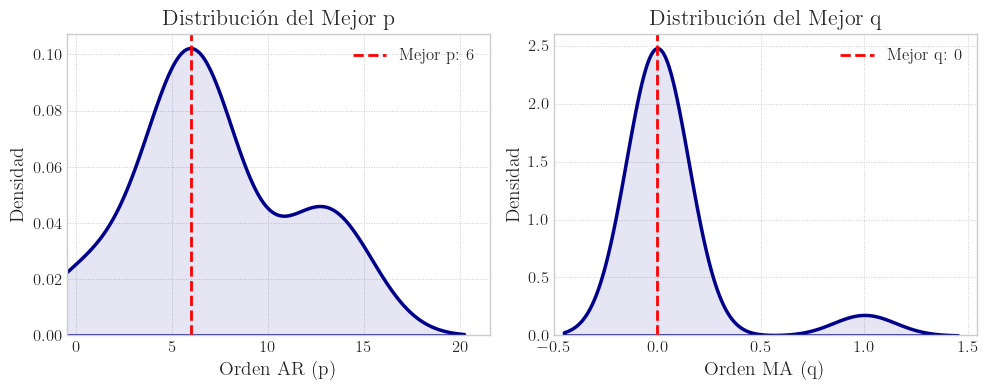

✅ Successfully saved figure to ./presentation/figures/p3/pq_hqic_ipc.pdf


Processing bootstrap iterations:   5%|▌         | 15/300 [12:37<3:59:47, 50.48s/it]


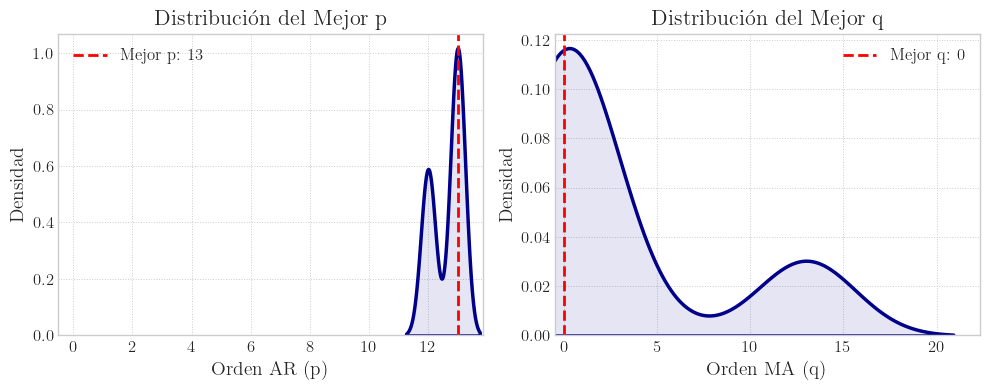

✅ Successfully saved figure to ./presentation/figures/p3/pq_hqic_imacec.pdf


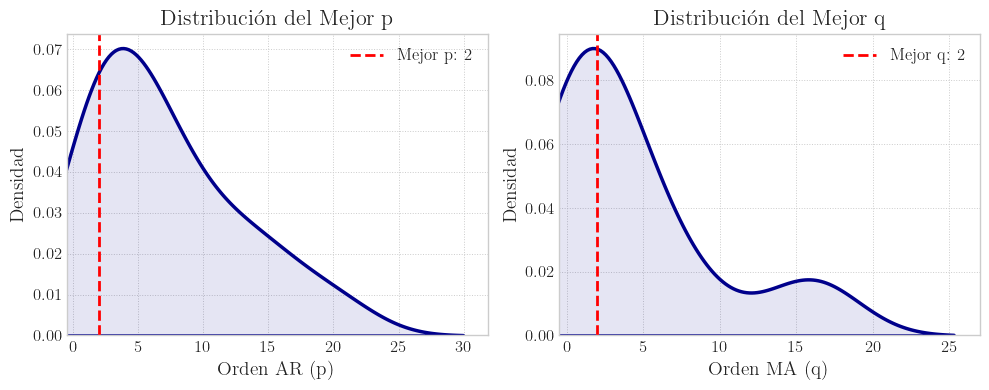

✅ Successfully saved figure to ./presentation/figures/p3/pq_hqic_tpm.pdf


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig, axes = uplot.plot_bootstrap_kde(results_ipc, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/pq_{}_ipc.pdf'.format(criteria))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig, axes = uplot.plot_bootstrap_kde(results_imacec, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/pq_{}_imacec.pdf'.format(criteria))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig, axes = uplot.plot_bootstrap_kde(results_tpm, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p3/pq_{}_tpm.pdf'.format(criteria))

### Estacionaridad 

In [55]:
print(results_ipc['model'])

             ARMA(6, 0) Model Summary             
Is Stationary            : False
Mu (Unc. Mean)           : 0.0036
Sigma (Unc. Std.)        : inf
Error Std Dev (sigma)    : 0.0033
Constant (c)             : 0.0010
--------------------------------------------------
AR Coefficients (phi):
  phi_1    = 0.1176
  phi_2    = 0.0446
  phi_3    = 0.1207
  phi_4    = 0.0599
  phi_5    = 0.0709
  phi_6    = 0.2962
--------------------------------------------------
MA Coefficients (theta):
  (No MA coefficients)


In [56]:
print(results_imacec['model'])


            ARMA(13, 0) Model Summary             
Is Stationary            : False
Mu (Unc. Mean)           : 0.0023
Sigma (Unc. Std.)        : inf
Error Std Dev (sigma)    : 0.0217
Constant (c)             : 0.0037
--------------------------------------------------
AR Coefficients (phi):
  phi_1    = -0.0157
  phi_2    = -0.2161
  phi_3    = -0.1172
  phi_4    = -0.1635
  phi_5    = -0.0642
  phi_6    = -0.1423
  phi_7    = -0.0363
  phi_8    = -0.1104
  phi_9    = -0.0494
  phi_10   = -0.1735
  phi_11   = -0.1256
  phi_12   = 0.7384
  phi_13   = -0.1370
--------------------------------------------------
MA Coefficients (theta):
  (No MA coefficients)


In [54]:
print(results_tpm['model'])

             ARMA(2, 2) Model Summary             
Is Stationary            : True
Mu (Unc. Mean)           : 0.0463
Sigma (Unc. Std.)        : 0.0216
Error Std Dev (sigma)    : 0.0022
Constant (c)             : 0.0005
--------------------------------------------------
AR Coefficients (phi):
  phi_1    = 1.8466
  phi_2    = -0.8578
--------------------------------------------------
MA Coefficients (theta):
  theta_1    = -0.4706
  theta_2    = 0.0109


## IRF

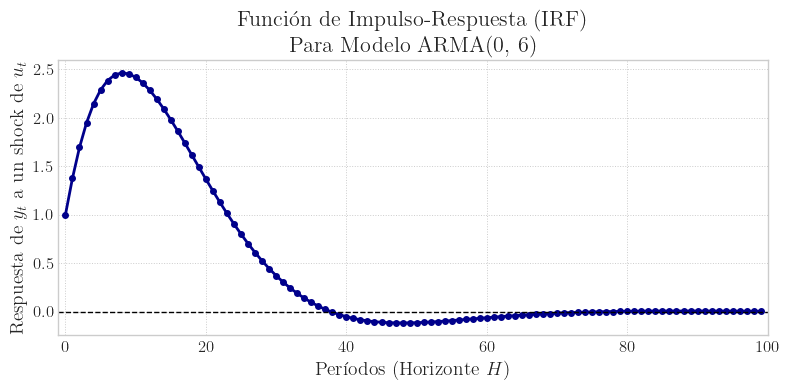

✅ Successfully saved figure to ./presentation/figures/p3/irf_ipc.pdf


In [67]:
irf_exact = results_tpm['model'].get_irf(H=100)

fig, axes = plt.subplots(1, 1, figsize=(8, 4))
fig, axes = uplot.plot_irf(irf_exact, model=results_ipc['model'], model_name="ARMA", fig=fig, ax=axes)

uplot.save_figure(fig, path='./presentation/figures/p3/irf_ipc.pdf')

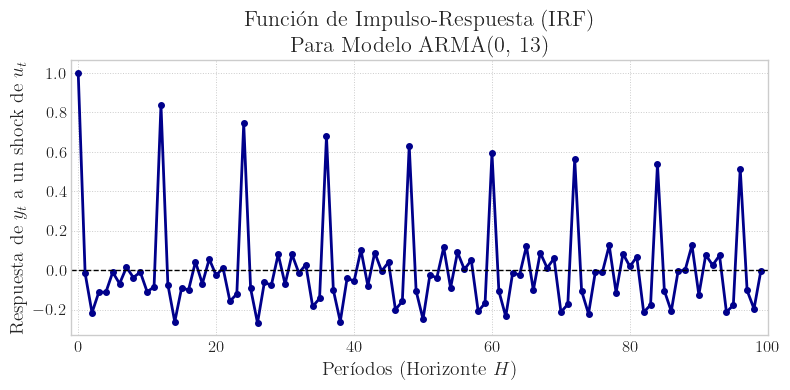

✅ Successfully saved figure to ./presentation/figures/p3/irf_imacec.pdf


In [70]:
irf_exact = results_imacec['model'].get_irf(H=100)

fig, axes = plt.subplots(1, 1, figsize=(8, 4))
fig, axes = uplot.plot_irf(irf_exact, model=results_imacec['model'], model_name="ARMA", fig=fig, ax=axes)

uplot.save_figure(fig, path='./presentation/figures/p3/irf_imacec.pdf')

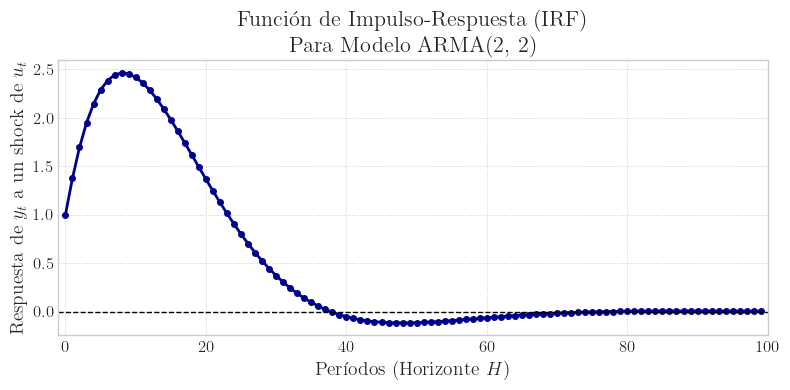

✅ Successfully saved figure to ./presentation/figures/p3/irf_tpm.pdf


In [71]:
irf_exact = results_tpm['model'].get_irf(H=100)

fig, axes = plt.subplots(1, 1, figsize=(8, 4))
fig, axes = uplot.plot_irf(irf_exact, model=results_tpm['model'], model_name="ARMA", fig=fig, ax=axes)

uplot.save_figure(fig, path='./presentation/figures/p3/irf_tpm.pdf')

## Forecasting

In [72]:
ds0, ds1 = split_dataset(dataset, '2023-12-01')

In [75]:
pi_pred, pi_low, pi_up = results_ipc['model'].forecast_arma(ds0['pi_t'], h=len(ds1['pi_t']))
y_pred, y_low, y_up = results_imacec['model'].forecast_arma(ds0['y_t'], h=len(ds1['y_t']))
i_pred, i_low, i_up = results_tpm['model'].forecast_arma(ds0['i_t'], h=len(ds1['i_t']))

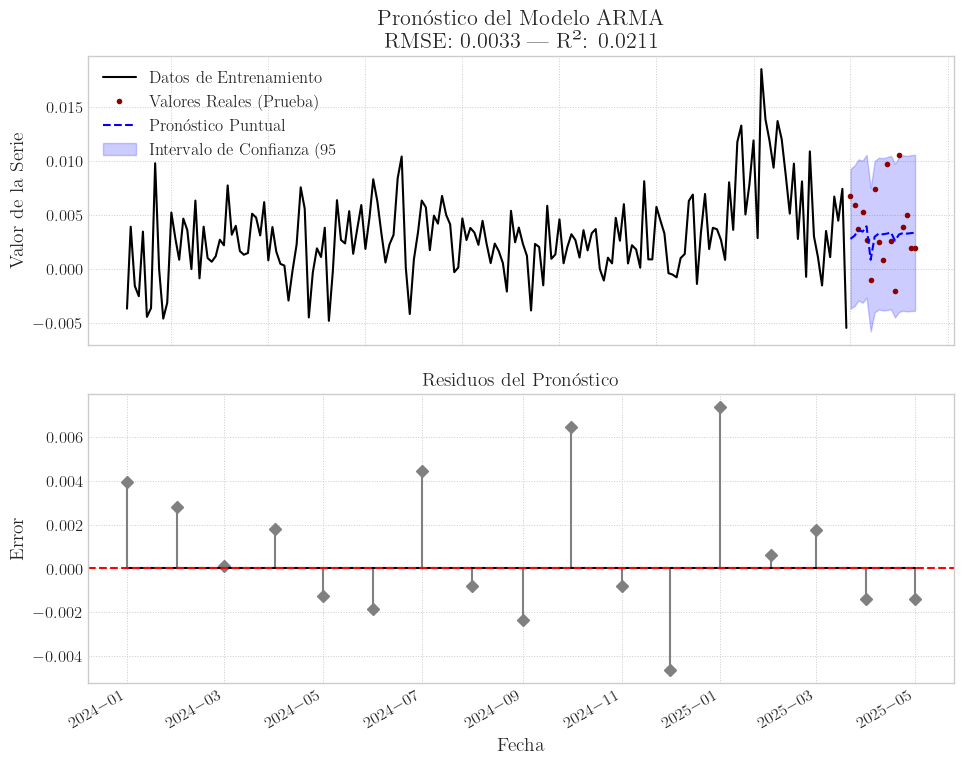

✅ Successfully saved figure to ./presentation/figures/p3/forecasting_ipc.pdf


In [76]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
fig, axes = plot_forecast(ds0['t'], 
              ds0['pi_t'],
              ds1['t'],
              ds1['pi_t'],
              pi_pred,
              pi_low,
              pi_up, model_name="ARMA", fig=fig, axes=axes)
uplot.save_figure(fig, path='./presentation/figures/p3/forecasting_ipc.pdf')

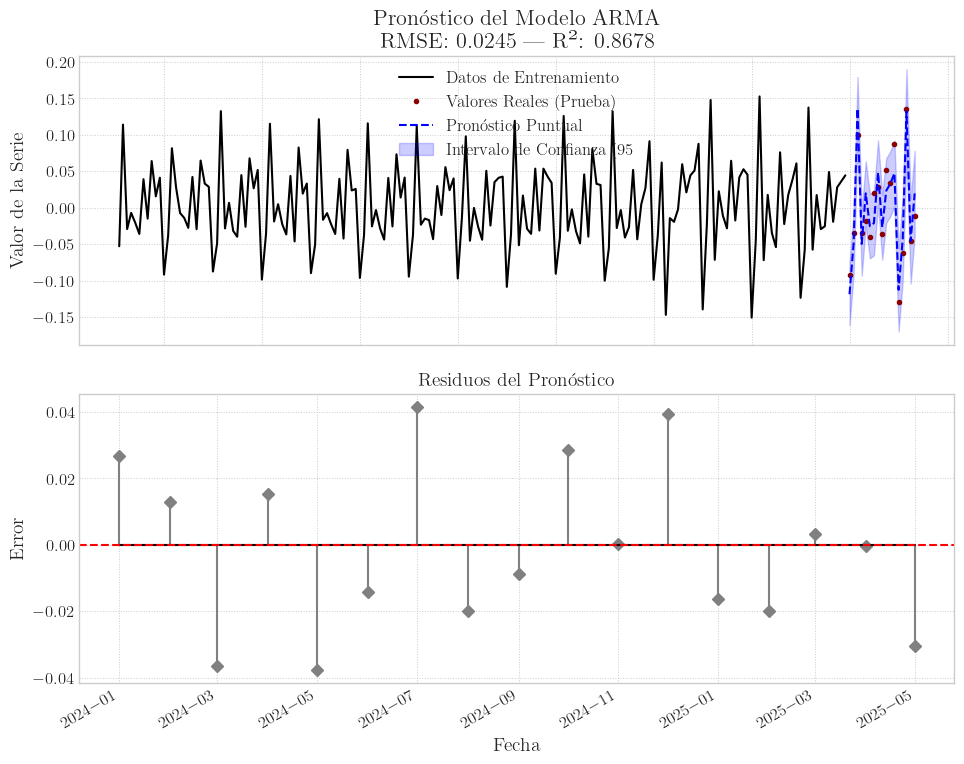

✅ Successfully saved figure to ./presentation/figures/p3/forecasting_imacec.pdf


In [79]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
fig, axes = plot_forecast(ds0['t'], 
              ds0['y_t'],
              ds1['t'],
              ds1['y_t'],
              y_pred,
              y_low,
              y_up, model_name="ARMA", fig=fig, axes=axes)
uplot.save_figure(fig, path='./presentation/figures/p3/forecasting_imacec.pdf')

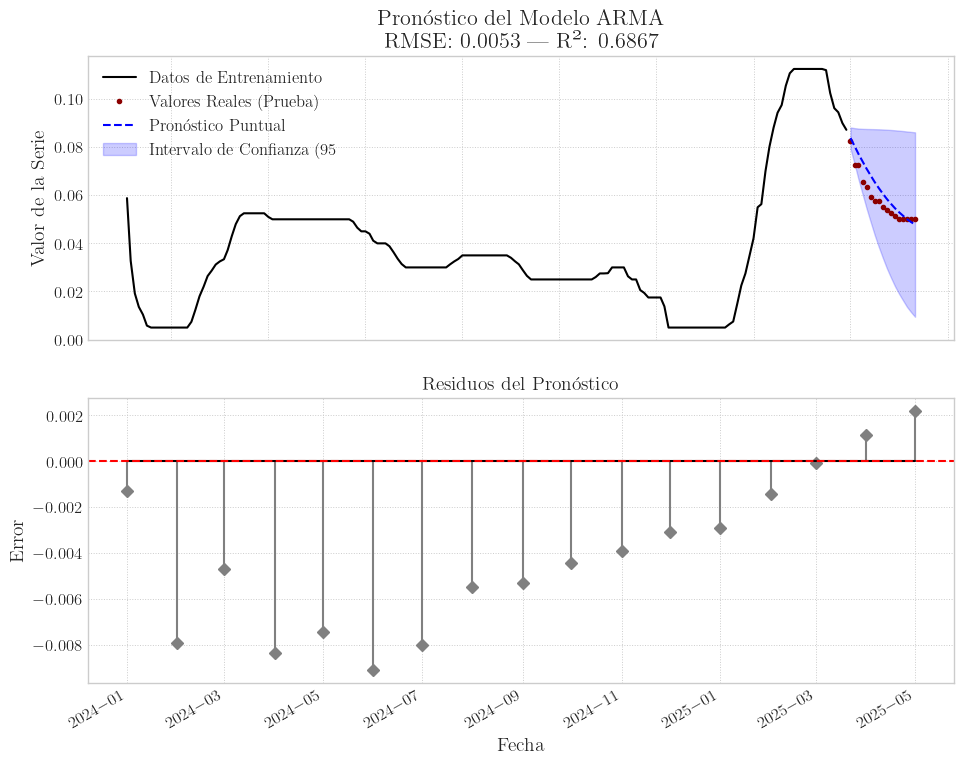

✅ Successfully saved figure to ./presentation/figures/p3/forecasting_tpm.pdf


In [80]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
fig, axes = plot_forecast(ds0['t'], 
              ds0['i_t'],
              ds1['t'],
              ds1['i_t'],
              i_pred,
              i_low,
              i_up, model_name="ARMA", fig=fig, axes=axes)
uplot.save_figure(fig, path='./presentation/figures/p3/forecasting_tpm.pdf')